**Installing Packages**

In [ ]:
!pip install tensorflow opencv-python matplotlib seaborn scikit-learn pandas

**Import Libraries**

In [11]:
import os
import cv2
import random
import shutil
import csv
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from datetime import datetime
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

**Dataset paths**

In [12]:
base_path = "/content/drive/MyDrive/NEU-DET"

train_dir = os.path.join(base_path, "train/images")
val_dir   = os.path.join(base_path, "validation/images")

print("Classes:", os.listdir(train_dir))

Classes: ['inclusion', 'pitted_surface', 'crazing', 'patches', 'rolled-in_scale', 'scratches']


**Initial Images**

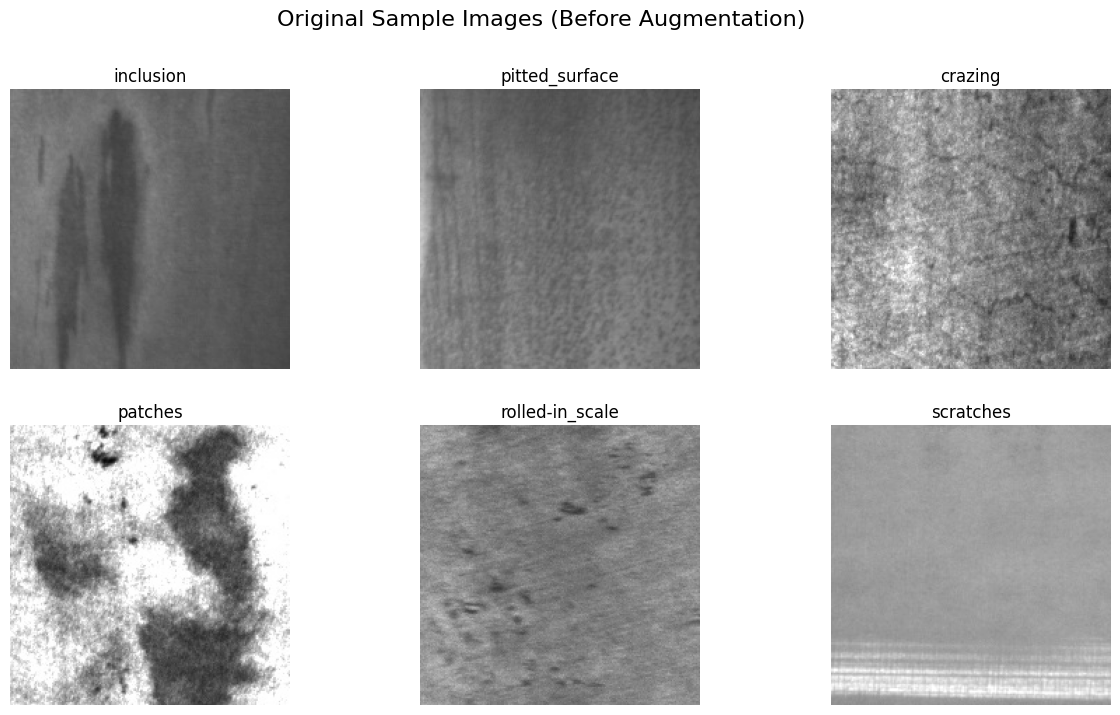

In [13]:
classes = os.listdir(train_dir)

plt.figure(figsize=(15,8))

for i, cls in enumerate(classes):
    img_path = os.path.join(train_dir, cls, random.choice(os.listdir(os.path.join(train_dir, cls))))
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.suptitle("Original Sample Images (Before Augmentation)", fontsize=16)
plt.show()

**Class Distribution Graph**

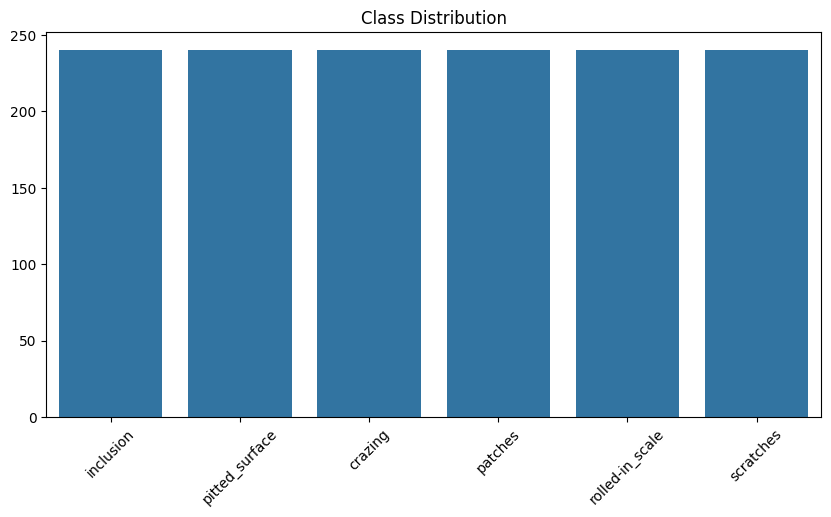

In [14]:
class_counts = {}

for cls in classes:
    class_counts[cls] = len(os.listdir(os.path.join(train_dir, cls)))

plt.figure(figsize=(10,5))
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.xticks(rotation=45)
plt.title("Class Distribution")
plt.show()

**Data Preprocessing & Augmentation**

In [15]:
img_size = 160
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size,img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

class_names = list(train_generator.class_indices.keys())
print("Detected Classes:", class_names)

Found 1440 images belonging to 6 classes.
Found 360 images belonging to 6 classes.
Detected Classes: ['crazing', 'inclusion', 'patches', 'pitted_surface', 'rolled-in_scale', 'scratches']


**Augmentation Example**

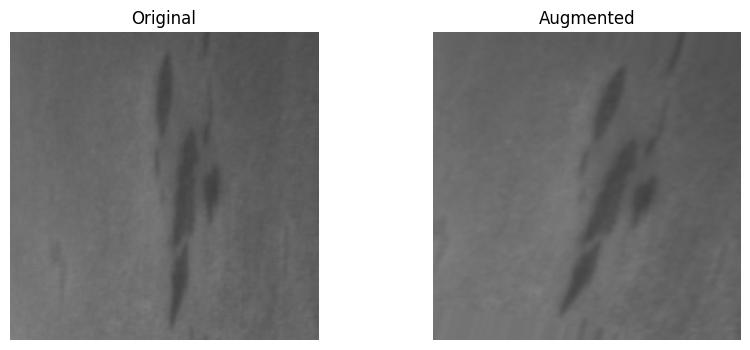

In [17]:
sample_img_path = os.path.join(
    train_dir,
    classes[0],
    random.choice(os.listdir(os.path.join(train_dir, classes[0])))
)

img = cv2.imread(sample_img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (img_size, img_size))

# IMPORTANT: Do NOT divide by 255 here
img = np.expand_dims(img, axis=0)

aug_iter = train_datagen.flow(img)

plt.figure(figsize=(10,4))

# Original
plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Original")
plt.axis("off")

# Augmented
augmented_img = next(aug_iter)[0]

# Since rescale=1./255 is applied inside generator,
# multiply back to display properly
plt.subplot(1,2,2)
plt.imshow(augmented_img)
plt.title("Augmented")
plt.axis("off")

plt.show()

**Class Weights**

In [18]:
y_train = train_generator.classes

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weights_dict)

Class Weights: {0: np.float64(1.0), 1: np.float64(1.0), 2: np.float64(1.0), 3: np.float64(1.0), 4: np.float64(1.0), 5: np.float64(1.0)}


**Build MobileNetV2 Model**

In [19]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(img_size,img_size,3)
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)
output = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


**Compile Model**

In [20]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 80, 80,    │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 80, 80,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 80, 80,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 80, 80,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 80, 80,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 80, 80,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 80, 80,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 80, 80,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 81, 81,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 40, 40,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 40, 40,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 40, 40,    │      2,304 │ block_1_depthwis

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Train Model**

In [21]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 54s 770ms/step - accuracy: 0.6670 - loss: 0.9190 - val_accuracy: 0.8944 - val_loss: 0.3141
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 413ms/step - accuracy: 0.9600 - loss: 0.1191 - val_accuracy: 0.9167 - val_loss: 0.2584
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 396ms/step - accuracy: 0.9820 - loss: 0.0665 - val_accuracy: 0.9306 - val_loss: 0.1977
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 393ms/step - accuracy: 0.9716 - loss: 0.0648 - val_accuracy: 0.9417 - val_loss: 0.1526
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 411ms/step - accuracy: 0.9874 - loss: 0.0457 - val_accuracy: 0.9444 - val_loss: 0.2101
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 393ms/step - accuracy: 0.9820 - loss: 0.0411 - val_accuracy: 0.9389 - val_loss: 0.2104
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 407ms/step - accuracy: 0.9882 - loss: 0.0345 - val_accuracy: 0.9444 - val_loss: 0.1756
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 397ms/step - accuracy: 0.9867 - loss: 0.0368 - val_accu

**Fine Tune Model**

In [24]:
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights_dict
)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 52s 609ms/step - accuracy: 0.8048 - loss: 0.7627 - val_accuracy: 0.9361 - val_loss: 0.1893
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 396ms/step - accuracy: 0.9806 - loss: 0.0776 - val_accuracy: 0.6667 - val_loss: 1.2364
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 451ms/step - accuracy: 0.9850 - loss: 0.0620 - val_accuracy: 0.8361 - val_loss: 0.5493
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 397ms/step - accuracy: 0.9881 - loss: 0.0385 - val_accuracy: 0.7750 - val_loss: 1.3451
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 395ms/step - accuracy: 0.9921 - loss: 0.0220 - val_accuracy: 0.8139 - val_loss: 1.0344
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 18s 405ms/step - accuracy: 0.9896 - loss: 0.0325 - val_accuracy: 0.7194 - val_loss: 1.7153
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 20s 439ms/step - accuracy: 0.9916 - loss: 0.0163 - val_accuracy: 0.9667 - val_loss: 0.1206
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 19s 416ms/step - accuracy: 0.9956 - loss: 0.0205 - val_accu

**Accuracy & Loss Graph**

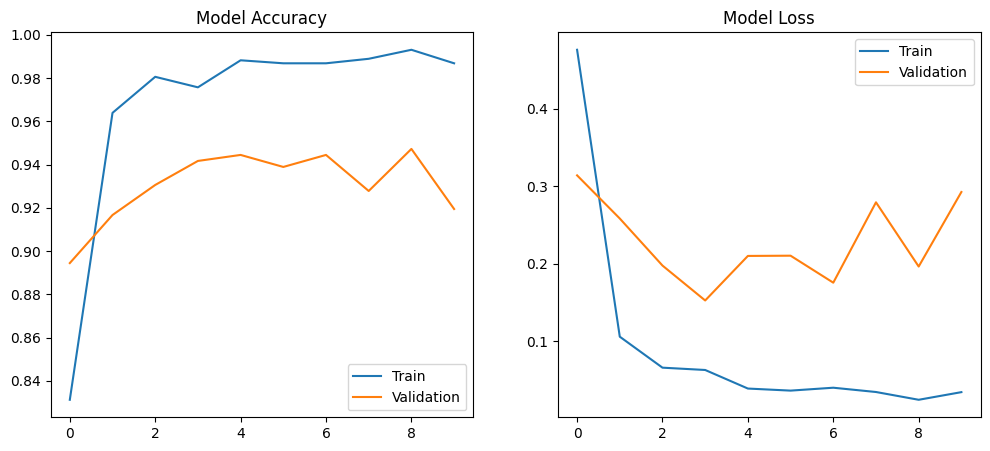

In [25]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Model Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Model Loss")
plt.legend()

plt.show()

**Confusion Matrix**

12/12 ━━━━━━━━━━━━━━━━━━━━ 13s 735ms/step


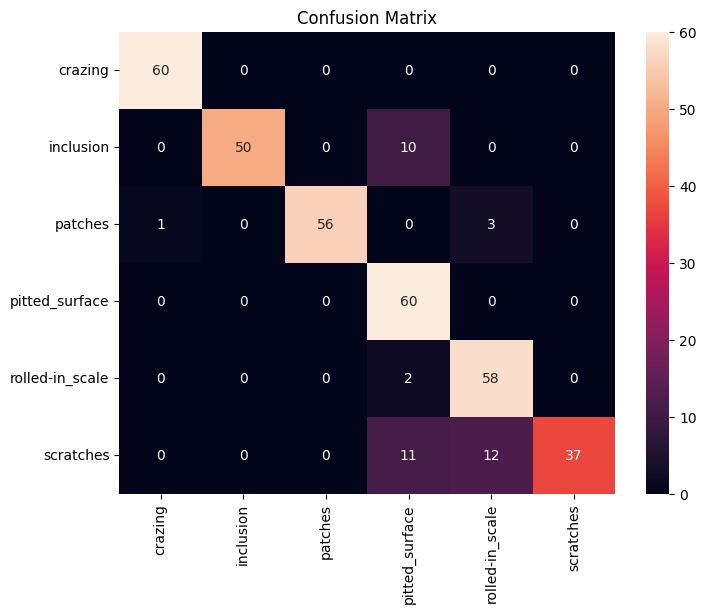

                 precision    recall  f1-score   support

        crazing       0.98      1.00      0.99        60
      inclusion       1.00      0.83      0.91        60
        patches       1.00      0.93      0.97        60
 pitted_surface       0.72      1.00      0.84        60
rolled-in_scale       0.79      0.97      0.87        60
      scratches       1.00      0.62      0.76        60

       accuracy                           0.89       360
      macro avg       0.92      0.89      0.89       360
   weighted avg       0.92      0.89      0.89       360



In [26]:
val_generator.reset()
y_pred = model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

cm = confusion_matrix(val_generator.classes, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=class_names,
            yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

print(classification_report(val_generator.classes, y_pred_classes, target_names=class_names))

**Save Model**

In [36]:
model.save("/content/drive/MyDrive/NEU_multiclass_model.h5")

**Logging Setup**

In [30]:
import os
import csv
from datetime import datetime

log_file = "/content/drive/MyDrive/defect_log.csv"

# Create file only if it doesn't exist
if not os.path.exists(log_file):
    with open(log_file, 'w', newline='') as f:
        writer = csv.writer(f)
        writer.writerow(["Timestamp","Image_Name","Predicted_Class","Confidence"])

print("Logging ready ✅")

Logging ready ✅


**Logging Function**

In [32]:
def log_prediction(file_name, cls, conf):
    with open(log_file, 'a', newline='') as f:
        writer = csv.writer(f)
        writer.writerow([datetime.now(), file_name, cls, float(conf)])

**Real-Time Detection**

Saving inclusion_247.jpg to inclusion_247.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
Prediction: inclusion
Confidence: 0.9844


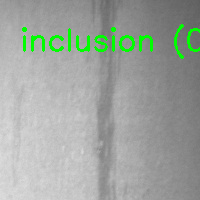

In [38]:
from google.colab import files
from google.colab.patches import cv2_imshow

uploaded = files.upload()

for file_name in uploaded.keys():

    # Read image
    img = cv2.imread(file_name)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize to model input
    img_resized = cv2.resize(img_rgb, (img_size, img_size))

    # Normalize (VERY IMPORTANT)
    img_resized = img_resized / 255.0

    # Expand dims
    img_resized = np.expand_dims(img_resized, axis=0)

    # Predict
    pred = model.predict(img_resized)
    cls = class_names[np.argmax(pred)]
    conf = np.max(pred)

    print("Prediction:", cls)
    print("Confidence:", round(float(conf),4))

    # Logging
    log_prediction(file_name, cls, conf)

    # Put text on original image
    cv2.putText(img,
                f"{cls} ({conf:.2f})",
                (20,50),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0,255,0),
                2)

    cv2_imshow(img)